## script for Question 3

In [113]:
import os 
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import numpy as np 

### Import section to understand wordpiece token

In [24]:

from transformers import BertTokenizer, BertModel

# Load the tokenizer and model
tokenizer = BertTokenizer.from_pretrained('datasets/bert-base-uncased')
model = BertModel.from_pretrained('datasets/bert-base-uncased')

# Example input text
text = "Hello, world! I like China."

# Tokenize the input text
tokens = tokenizer(text, return_tensors="pt")
print(tokens)
# Get the embeddings
with torch.no_grad():
    word_embeddings = model.embeddings.word_embeddings(tokens['input_ids'])
    position_ids = torch.arange(tokens['input_ids'].size(1), dtype=torch.long).unsqueeze(0)
    position_embeddings = model.embeddings.position_embeddings(position_ids)
    token_type_embeddings = model.embeddings.token_type_embeddings(tokens['token_type_ids'])
    
    # Sum the embeddings element-wise
    combined_embeddings = word_embeddings + position_embeddings + token_type_embeddings

    # Apply LayerNorm and Dropout
    layernorm = model.embeddings.LayerNorm(combined_embeddings)
    embeddings = model.embeddings.dropout(layernorm)

print(embeddings.shape)  # Output: torch.Size([1, 10, 768])

{'input_ids': tensor([[ 101, 7592, 1010, 2088,  999, 1045, 2066, 2859, 1012,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
torch.Size([1, 10, 768])


#### Import package

In [114]:
from transformers import BertForSequenceClassification,Trainer,TrainingArguments,AutoTokenizer
from datasets import load_dataset

In [3]:
# Load dataset
dataset = load_dataset ("datasets/ag_news") 

In [26]:
# Load model and tokenizer
model = BertForSequenceClassification.from_pretrained ("datasets/bert-base-uncased", num_labels =4)
tokenizer = AutoTokenizer.from_pretrained ("datasets/bert-base-uncased")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at datasets/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
tokenizer 

BertTokenizerFast(name_or_path='datasets/bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [28]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [29]:
# Preprocess data
def preprocess_function(examples):
    return tokenizer(examples ['text'], truncation =True , padding='max_length', max_length=512)

encoded_dataset = dataset.map(preprocess_function,batched = True)

In [ ]:
# Training Arguments with adjustments
training_args = TrainingArguments(
    output_dir="./results",                      # output directory
    evaluation_strategy="epoch",                 # evaluate after each epoch
    save_strategy="epoch",                       # save model after each epoch
    learning_rate=2e-5,                          # learning rate
    per_device_train_batch_size=16,              # increased batch size
    num_train_epochs=3,                          # number of training epochs
    gradient_accumulation_steps=2,               # Accumulate gradients over 2 steps
    fp16=True                                    # enable mixed precision training
)

# Trainer Setup
trainer = Trainer(
    model=model,                                 # the instantiated 🤗 Transformers model to be trained
    args=training_args,                          # training arguments
    train_dataset=encoded_dataset["train"],      # training dataset
    eval_dataset=encoded_dataset["test"]         # evaluation dataset
)

# Start training
trainer.train()

trained_model_output_dir = "./trained_model"
model.save_pretrained(trained_model_output_dir)
tokenizer.save_pretrained(trained_model_output_dir) 

## 3.4 Extract attention map

## 3.5 test with examples

#### test the trained model with different input 

In [37]:
from transformers import BertForSequenceClassification, AutoTokenizer
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader
import torchmetrics

# Load the trained model and tokenizer
model_dir = "./trained_model"
model = BertForSequenceClassification.from_pretrained(model_dir, num_labels=4)
tokenizer = AutoTokenizer.from_pretrained(model_dir)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Assuming the label mapping is as follows (update this according to your dataset):
label_mapping = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# Example input text to see predictions
input_text = ["The stock market is experiencing a significant downturn.",
              "Thousands braved heavy snow in Seoul on Sunday to rally for and against arresting impeached President Yoon Suk Yeol, as South Korea's political crisis appeared headed toward another high-stakes confrontation.",
              "The Massachusetts Legislature approved a bill Monday aimed at closing loopholes in the state’s health care market regulatory process exposed by the collapse of Steward Health Care."]

# Tokenize the input text
inputs = tokenizer(input_text, return_tensors="pt", padding=True, truncation=True, max_length=512)

# Move the inputs to the correct device
inputs = {key: value.to(device) for key, value in inputs.items()}

# Make predictions
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)

# Get the predicted labels
predicted_labels = [label_mapping[prediction.item()] for prediction in predictions]

# Print predictions
for text, label in zip(input_text, predicted_labels):
    print(f"Text: {text}\nPredicted label: {label}\n")

Text: The stock market is experiencing a significant downturn.
Predicted label: Business

Text: Thousands braved heavy snow in Seoul on Sunday to rally for and against arresting impeached President Yoon Suk Yeol, as South Korea's political crisis appeared headed toward another high-stakes confrontation.
Predicted label: World

Text: The Massachusetts Legislature approved a bill Monday aimed at closing loopholes in the state’s health care market regulatory process exposed by the collapse of Steward Health Care.
Predicted label: Business



#### Test the model performance on fine-tune model

In [103]:
from transformers import BertForSequenceClassification, AutoTokenizer
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader
import torchmetrics

# Load the trained model and tokenizer
model_dir = "./trained_model"
model = BertForSequenceClassification.from_pretrained(model_dir, num_labels=4)
tokenizer = AutoTokenizer.from_pretrained(model_dir)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Load the AG News test dataset
test_dataset = load_dataset('datasets/ag_news', split='test')

# Preprocess the test data
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=512)

encoded_test_dataset = test_dataset.map(preprocess_function, batched=True)

# Create a DataLoader for the test dataset
def collate_fn(batch):
    input_ids = torch.stack([torch.tensor(item['input_ids']) for item in batch])
    attention_mask = torch.stack([torch.tensor(item['attention_mask']) for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

test_dataloader = DataLoader(encoded_test_dataset, batch_size=16, collate_fn=collate_fn)

# Put the model in evaluation mode
model.eval()

# Initialize metrics
accuracy_metric = torchmetrics.Accuracy(task='multiclass', num_classes=4).to(device)
precision_metric = torchmetrics.Precision(task='multiclass', average='weighted', num_classes=4).to(device)
recall_metric = torchmetrics.Recall(task='multiclass', average='weighted', num_classes=4).to(device)
f1_metric = torchmetrics.F1Score(task='multiclass', average='weighted', num_classes=4).to(device)


In [107]:

# Disable gradient calculation for inference
with torch.no_grad():
    for batch in test_dataloader:
        inputs = {key: value.to(device) for key, value in batch.items() if key != 'labels'}
        labels = batch['labels'].to(device)
        outputs = model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)
        
        # Update metrics
        accuracy_metric.update(preds, labels)
        precision_metric.update(preds, labels)
        recall_metric.update(preds, labels)
        f1_metric.update(preds, labels)

# Compute the metrics
accuracy = accuracy_metric.compute().item()
precision = precision_metric.compute().item()
recall = recall_metric.compute().item()
f1 = f1_metric.compute().item()

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.9461
Precision: 0.9462
Recall: 0.9461
F1 Score: 0.9461


#### result of fine-tuned model performance on testset
Accuracy: 0.9461
Precision: 0.9462
Recall: 0.9461
F1 Score: 0.9461

#### Test the model performance on pre-trained model

In [110]:
from transformers import BertForSequenceClassification, AutoTokenizer
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader
import torchmetrics

# Load pre-trained model and tokenizer
model = BertForSequenceClassification.from_pretrained ("datasets/bert-base-uncased", num_labels =4)
tokenizer = AutoTokenizer.from_pretrained ("datasets/bert-base-uncased")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Load the AG News test dataset
test_dataset = load_dataset('datasets/ag_news', split='test')

# Preprocess the test data
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=512)

encoded_test_dataset = test_dataset.map(preprocess_function, batched=True)

# Create a DataLoader for the test dataset
def collate_fn(batch):
    input_ids = torch.stack([torch.tensor(item['input_ids']) for item in batch])
    attention_mask = torch.stack([torch.tensor(item['attention_mask']) for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

test_dataloader = DataLoader(encoded_test_dataset, batch_size=16, collate_fn=collate_fn)

# Put the model in evaluation mode
model.eval()

# Initialize metrics
accuracy_metric = torchmetrics.Accuracy(task='multiclass', num_classes=4).to(device)
precision_metric = torchmetrics.Precision(task='multiclass', average='weighted', num_classes=4).to(device)
recall_metric = torchmetrics.Recall(task='multiclass', average='weighted', num_classes=4).to(device)
f1_metric = torchmetrics.F1Score(task='multiclass', average='weighted', num_classes=4).to(device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at datasets/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 7600/7600 [00:01<00:00, 3813.54 examples/s]


In [111]:
# Disable gradient calculation for inference
with torch.no_grad():
    for batch in test_dataloader:
        inputs = {key: value.to(device) for key, value in batch.items() if key != 'labels'}
        labels = batch['labels'].to(device)
        outputs = model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)
        
        # Update metrics
        accuracy_metric.update(preds, labels)
        precision_metric.update(preds, labels)
        recall_metric.update(preds, labels)
        f1_metric.update(preds, labels)

# Compute the metrics
accuracy = accuracy_metric.compute().item()
precision = precision_metric.compute().item()
recall = recall_metric.compute().item()
f1 = f1_metric.compute().item()

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.2675
Precision: 0.1698
Recall: 0.2675
F1 Score: 0.1473


#### result of pre-trained model performance on testset
Accuracy: 0.2675
Precision: 0.1698
Recall: 0.2675
F1 Score: 0.1473

## Attention map of different samples 

In [29]:
attentions_pretrained[-1].shape

torch.Size([1, 12, 33, 33])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at datasets/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


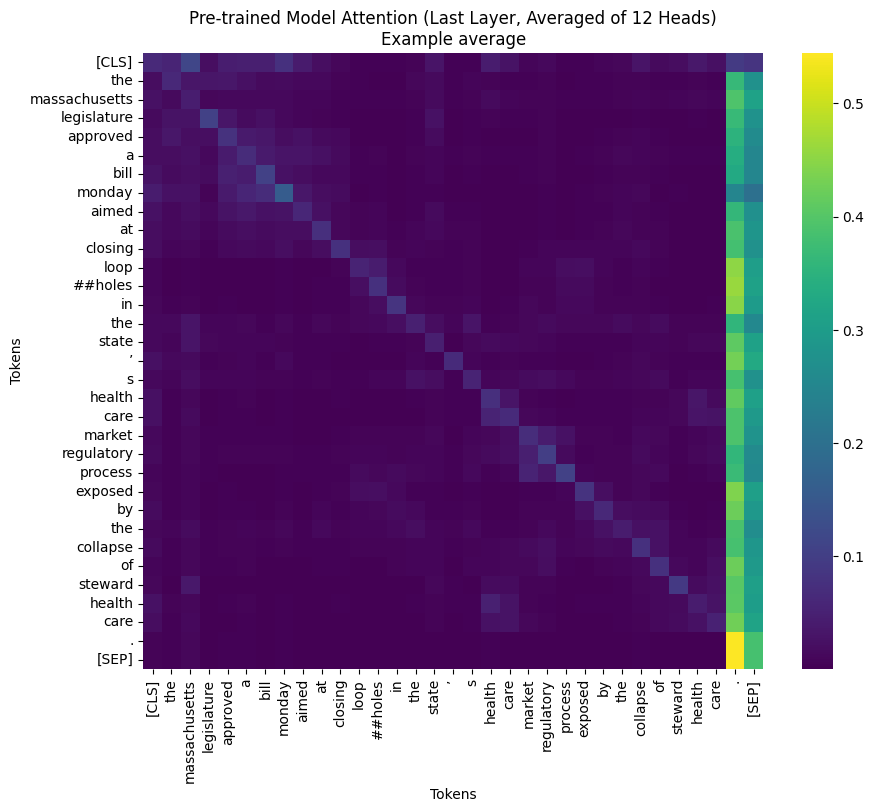

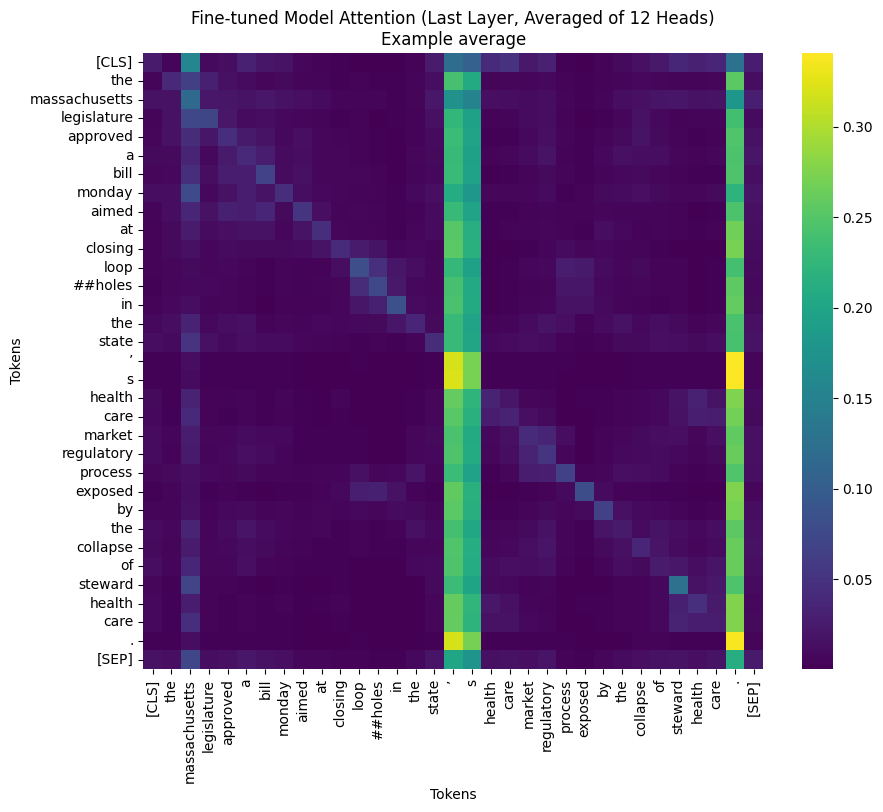

In [24]:
import torch
from transformers import AutoTokenizer, BertForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns

# Load the pre-trained and fine-tuned models and tokenizer
pretrained_model_dir = "datasets/bert-base-uncased"
fine_tuned_model_dir = "./trained_model"
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_dir)
model_pretrained = BertForSequenceClassification.from_pretrained(pretrained_model_dir, num_labels=4, output_attentions=True)
model_fineTuned = BertForSequenceClassification.from_pretrained(fine_tuned_model_dir, num_labels=4, output_attentions=True)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pretrained.to(device)
model_fineTuned.to(device)

# Example input text
input_text = ["The Massachusetts Legislature approved a bill Monday aimed at closing loopholes in the state’s health care market regulatory process exposed by the collapse of Steward Health Care."]

# Tokenize the input text
inputs = tokenizer(input_text, return_tensors="pt", padding=True, truncation=True, max_length=512)

# Move the inputs to the correct device
inputs = {key: value.to(device) for key, value in inputs.items()}

# Get attentions for both models
# Pre-trained
model_pretrained.eval()
with torch.no_grad():
    outputs_pretrained = model_pretrained(**inputs)
attentions_pretrained = outputs_pretrained.attentions

# Fine-tuned
model_fineTuned.eval()
with torch.no_grad():
    outputs_fineTuned = model_fineTuned(**inputs)
attentions_fineTuned = outputs_fineTuned.attentions

# Function to visualize attention
def plot_attention(attention_map, title, tokens):
    avg_attention = attention_map.mean(dim=1).detach().cpu().numpy()  # Average across heads
    plt.figure(figsize=(10, 8))
    sns.heatmap(avg_attention[0], cmap="viridis", xticklabels=tokens, yticklabels=tokens)
    plt.title(title)
    plt.xlabel("Tokens")
    plt.ylabel("Tokens")
    plt.show()

# Get tokens
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Visualize attention from the last layer, averaged across heads
# Pre-trained attention
plot_attention(attentions_pretrained[-1], "Pre-trained Model Attention (Last Layer, Averaged of 12 Heads)\nExample average", tokens)

# Fine-tuned attention
plot_attention(attentions_fineTuned[-1], "Fine-tuned Model Attention (Last Layer, Averaged of 12 Heads)\nExample average", tokens)